# AGNDisk Demo

This notebook demonstrates how to use the `AGNDisk` class from `disktab.py` to generate Shakura-Sunyaev AGN disk profiles using Newton's method.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from astropy import units as u
import numpy as np
from disktab import AGNDisk
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from astropy.constants import G, c

## Basic Usage

Create an `AGNDisk` object and set the required physical parameters:
- `M`: Central black hole mass
- `Mdot`: Mass accretion rate
- `alpha`: Shakura-Sunyaev viscosity parameter

In [2]:
# Create disk object
disk = AGNDisk()

# Set required parameters
disk.M = 1e8 * u.Msun          # Central black hole mass
disk.Mdot = 1e23 * u.kg / u.s  # Mass accretion rate
disk.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

# Generate the disk profile
# rvals can be passed as dimensionless (multiples of Rg) or with units
# If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
disk.generate(rvals=np.logspace(1, 7, 200))

print(f"Gravitational radius: {disk.gRad.to(u.AU):.4f}")
print(f"Inner boundary (Rstar): {(disk.Rstar / disk.gRad).decompose():.1f} Rg")

Gravitational radius: 0.9871 AU
Inner boundary (Rstar): 6.0 Rg


In [3]:
disk.model

,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,zone
0,1.476625e+12,1.000000e+01,357328.173863,7.111188e-09,4.111521e+06,2.404530e+07,3.745240e+11,9.005542e+17,2663.310494,2.764415e+09,Standard
1,1.582782e+12,1.071891e+01,348145.509022,6.327184e-09,3.704900e+06,2.419820e+07,4.182719e+11,1.012143e+18,2646.482732,2.522799e+09,Standard
2,1.696570e+12,1.148951e+01,339198.780970,5.792195e-09,3.338493e+06,2.400787e+07,4.605273e+11,1.105628e+18,2667.463739,2.237679e+09,Standard
3,1.818538e+12,1.231551e+01,330481.937471,5.423920e-09,3.008321e+06,2.355079e+07,5.013412e+11,1.180698e+18,2719.234187,1.940329e+09,Standard
4,1.949276e+12,1.320088e+01,321989.076991,5.173597e-09,2.710803e+06,2.289036e+07,5.407627e+11,1.237826e+18,2797.687908,1.651748e+09,Standard
...,...,...,...,...,...,...,...,...,...,...,...
195,1.118580e+18,7.575250e+06,92.144628,2.261124e-17,1.787543e-08,2.811681e+04,2.887427e+17,8.118524e+20,13.057662,1.000000e+00,Self-Reg
196,1.198997e+18,8.119845e+06,87.471808,1.835998e-17,1.451487e-08,2.811709e+04,3.204362e+17,9.009735e+20,11.766403,1.000000e+00,Self-Reg
197,1.285194e+18,8.703591e+06,83.035855,1.490802e-17,1.178608e-08,2.811737e+04,3.556083e+17,9.998771e+20,10.602830,1.000000e+00,Self-Reg
198,1.377588e+18,9.329304e+06,78.824770,1.210508e-17,9.570292e-09,2.811763e+04,3.946410e+17,1.109637e+21,9.554320,1.000000e+00,Self-Reg


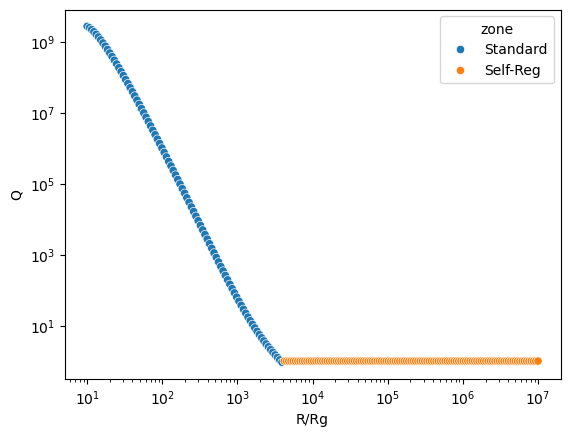

In [4]:
sns.scatterplot(data=disk.model, x="R/Rg", y="Q", hue="zone")
plt.xscale("log")
plt.yscale("log")

/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/disktab.py:892: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


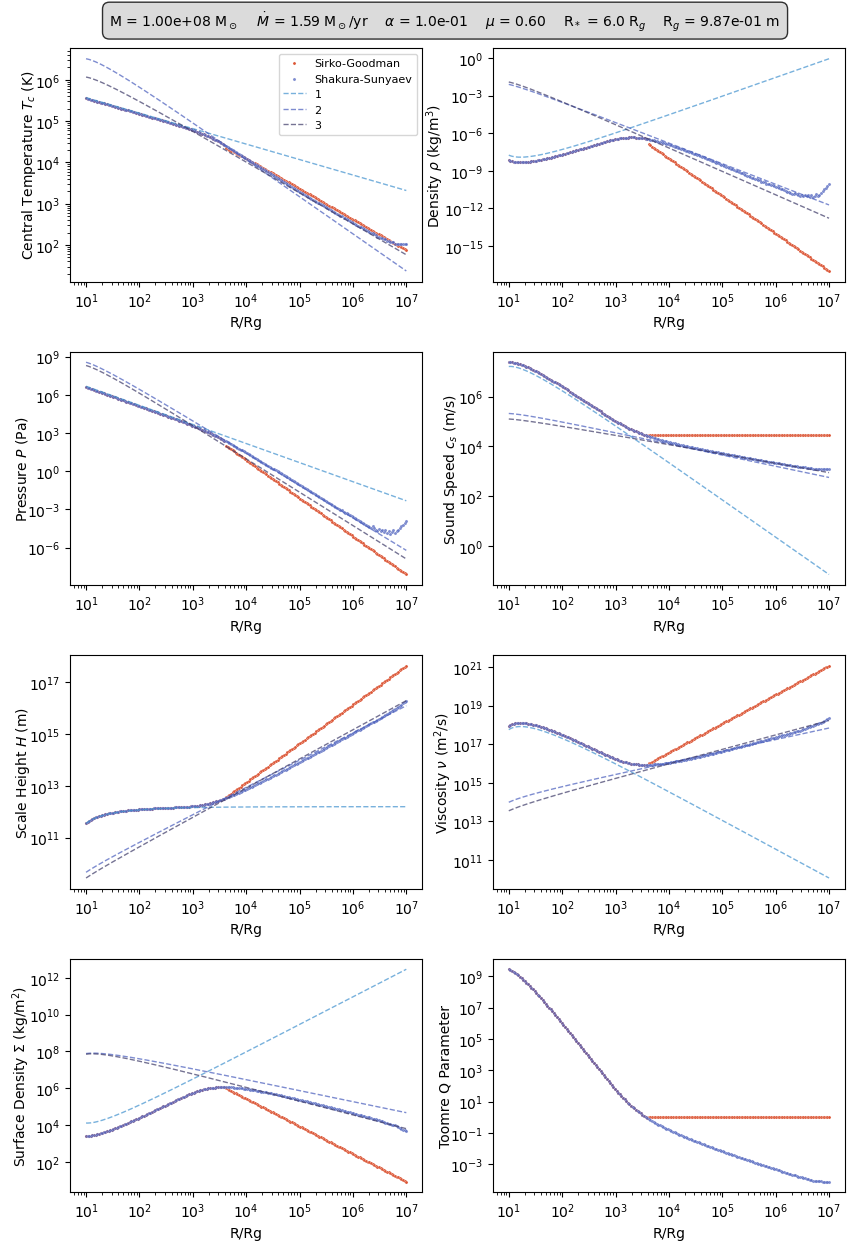

In [5]:
fig, axs = disk.layout(include_standard=True)

In [6]:
#fig.savefig("DiskModel.pdf")

## SpaceHub Unit Conversion

Convert the disk model to SpaceHub's native unit system for use with the N-body integrator.

SpaceHub uses:
- Mass: Solar masses (M☉)
- Length: AU
- Time: year/(2π), so that G = 1 and 1 year = 2π
- Temperature: Kelvin

In [7]:
# Convert to SpaceHub units
df_spacehub = disk.spacehub_pretab()

# Display first few rows
print("Disk model in SpaceHub units (M☉, AU, yr/2π):")
df_spacehub.head(10)

Disk model in SpaceHub units (M☉, AU, yr/2π):


,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,zone
0,9.870629,10.000000,357328.173863,0.000012,7.803190,807.302712,2.503539,202.111342,0.000030,2.764415e+09,Standard
1,10.580241,10.718913,348145.509022,0.000011,7.031471,812.436239,2.795975,227.155140,0.000030,2.522799e+09,Standard
2,11.340869,11.489510,339198.780970,0.000010,6.336072,806.046067,3.078435,248.136043,0.000030,2.237679e+09,Standard
3,12.156179,12.315506,330481.937471,0.000009,5.709446,790.699988,3.351259,264.984042,0.000031,1.940329e+09,Standard
4,13.030102,13.200884,321989.076991,0.000009,5.144790,768.526709,3.614776,277.805166,0.000031,1.651748e+09,Standard
5,13.966854,14.149913,313714.447480,0.000008,4.635978,741.283267,3.869303,286.824940,0.000033,1.384740e+09,Standard
6,14.970949,15.167169,305652.441877,0.000008,4.177486,710.412690,4.115147,292.345268,0.000034,1.146029e+09,Standard
7,16.047231,16.257557,297797.596758,0.000008,3.764338,677.093220,4.352605,294.711925,0.000036,9.380913e+08,Standard
8,17.200887,17.426334,290144.588199,0.000008,3.392049,642.280331,4.581963,294.290440,0.000038,7.606269e+08,Standard
9,18.437482,18.679136,282688.228041,0.000008,3.056578,606.742535,4.803497,291.448566,0.000040,6.116537e+08,Standard


In [8]:
# Verify unit conversions are correct
# Compare first row values between SI and SpaceHub units

AU_m = 1.495978707e11  # meters per AU
Msun_kg = 1.98847e30   # kg per solar mass
year_s = 365.25636042 * 24 * 3600
T_unit = year_s / (2 * np.pi)  # SpaceHub time unit in seconds

row_si = disk.model.iloc[0]
row_sh = df_spacehub.iloc[0]

print("Unit conversion verification (first row):")
print("=" * 60)
print(f"{'Quantity':<12} {'SI Value':<15} {'SpaceHub Value':<15} {'Expected':<15}")
print("-" * 60)
print(f"{'R':<12} {row_si['R']:<15.4e} {row_sh['R']:<15.4e} {row_si['R']/AU_m:<15.4e} (AU)")
print(f"{'H':<12} {row_si['H']:<15.4e} {row_sh['H']:<15.4e} {row_si['H']/AU_m:<15.4e} (AU)")
print(f"{'cs':<12} {row_si['cs']:<15.4e} {row_sh['cs']:<15.4e} {row_si['cs']*T_unit/AU_m:<15.4e} (AU/T)")
print(f"{'Tc':<12} {row_si['Tc']:<15.4e} {row_sh['Tc']:<15.4e} {row_si['Tc']:<15.4e} (K, unchanged)")
print(f"{'Q':<12} {row_si['Q']:<15.4e} {row_sh['Q']:<15.4e} {row_si['Q']:<15.4e} (dimensionless)")
print("=" * 60)
print("Conversions verified!" if np.isclose(row_sh['R'], row_si['R']/AU_m) else "ERROR in conversions!")

Unit conversion verification (first row):
Quantity     SI Value        SpaceHub Value  Expected       
------------------------------------------------------------
R            1.4766e+12      9.8706e+00      9.8706e+00      (AU)
H            3.7452e+11      2.5035e+00      2.5035e+00      (AU)
cs           2.4045e+07      8.0730e+02      8.0730e+02      (AU/T)
Tc           3.5733e+05      3.5733e+05      3.5733e+05      (K, unchanged)
Q            2.7644e+09      2.7644e+09      2.7644e+09      (dimensionless)
Conversions verified!
